# Actividad 5: Procesamiento de conjuntos de datos en Python

Primeras filas del dataset original:


,Tiempo (s),Distancia (cm),Velocidad (cm/s),Temperatura (°C)
0,1,50.2,10.5,22.1
1,2,45.1,12.0,22.5
2,3,NaN,11.2,22.3
3,4,30.5,-5.0,23.0
4,5,20.1,8.5,22.8


Dataset después de eliminar nulos y velocidades negativas:


,Tiempo (s),Distancia (cm),Velocidad (cm/s),Temperatura (°C)
0,1,50.2,10.5,22.1
1,2,45.1,12.0,22.5
4,5,20.1,8.5,22.8
7,8,5.5,7.2,24.0
8,9,100.0,150.0,22.0
9,10,45.0,10.0,22.2


Dataset Normalizado (Rango 0-1):


,Tiempo (s),Distancia (cm),Velocidad (cm/s),Temperatura (°C)
0,1,0.473016,0.023109,0.05
1,2,0.419048,0.033613,0.25
4,5,0.154497,0.009104,0.40
7,8,0.000000,0.000000,1.00
8,9,1.000000,1.000000,0.00


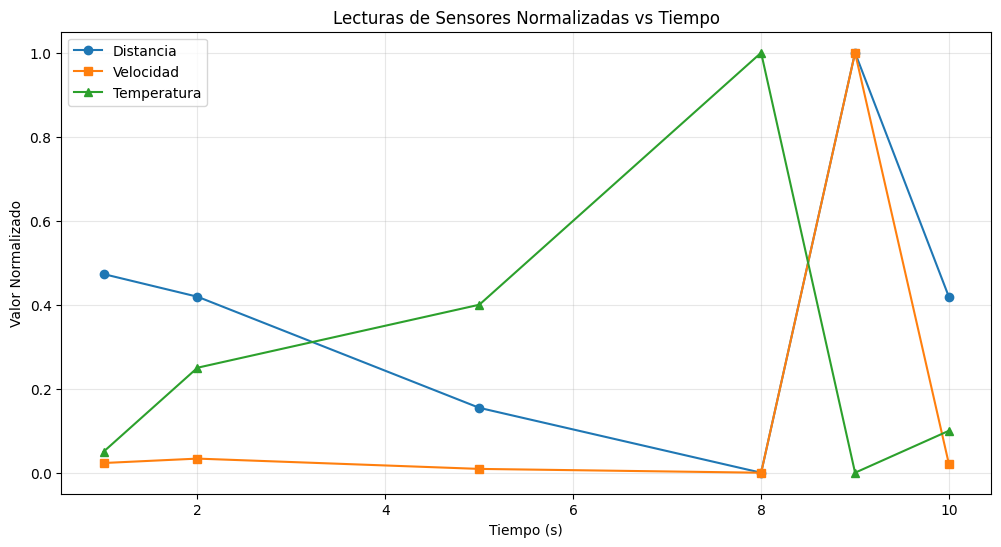

In [2]:
# AF5: Análisis y normalización de datos de sensores en un robot móvil
# Autores:
# Ximena Yamileth Salas Tamez       2103165
# Ivan Emiliano Villalobos Martinez 2178101
# Ricardo Bolaños Carreón           2178095
# Angel Armando Cortez Salazar      2045213
# Luis Fernando Pérez Resendiz      2178049

from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Crear dataset de ejemplo para propósitos del ejercicio
data = {
    'Tiempo (s)': np.arange(1, 11),
    'Distancia (cm)': [50.2, 45.1, np.nan, 30.5, 20.1, 15.0, 10.2, 5.5, 100.0, 45.0],
    'Velocidad (cm/s)': [10.5, 12.0, 11.2, -5.0, 8.5, 9.0, np.nan, 7.2, 150.0, 10.0],
    'Temperatura (°C)': [22.1, 22.5, 22.3, 23.0, 22.8, np.nan, 23.5, 24.0, 22.0, 22.2]
}
df_inicial = pd.DataFrame(data)
df_inicial.to_csv('robot_sensors.csv', index=False)

# 1. Cargar el dataset con pandas
df = pd.read_csv('robot_sensors.csv')

# 2. Mostrar primeras filas
print("Primeras filas del dataset original:")
display(df.head())

# 3. Limpiar los datos
# Eliminar filas con valores nulos
df_cleaned = df.dropna().copy()

# Filtrar valores atípicos (Velocidad negativa y límites lógicos)
df_cleaned = df_cleaned[df_cleaned['Velocidad (cm/s)'] >= 0]

print("Dataset después de eliminar nulos y velocidades negativas:")
display(df_cleaned)

# 4. Normalizar los datos numéricos con Min-Max Scaling
scaler = MinMaxScaler()
cols_num = ['Distancia (cm)', 'Velocidad (cm/s)', 'Temperatura (°C)']

df_norm = df_cleaned.copy()
df_norm[cols_num] = scaler.fit_transform(df_cleaned[cols_num])

print("Dataset Normalizado (Rango 0-1):")
display(df_norm.head())

# 5. Visualizar los datos normalizados
plt.figure(figsize=(12, 6))
plt.plot(df_norm['Tiempo (s)'], df_norm['Distancia (cm)'], label='Distancia', marker='o')
plt.plot(df_norm['Tiempo (s)'], df_norm['Velocidad (cm/s)'], label='Velocidad', marker='s')
plt.plot(df_norm['Tiempo (s)'], df_norm['Temperatura (°C)'], label='Temperatura', marker='^')

plt.title('Lecturas de Sensores Normalizadas vs Tiempo')
plt.xlabel('Tiempo (s)')
plt.ylabel('Valor Normalizado')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
